In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


from scipy.sparse import linalg
import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import transpile, QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

## __COBA HAMILTONIAN MANUAL__ ##

hitung integral molekul dengan pyscf

In [2]:
from pyscf import gto, scf, ao2mo
from openfermion import FermionOperator, normal_ordered, jordan_wigner
from openfermion import get_sparse_operator, count_qubits
import scipy.sparse.linalg as spla
from scipy.linalg import expm
import numpy as np
import pandas as pd

# ── Bond lengths ──────────────────────────────────────────────────────
bond_lengths = np.array([
    #0.5, 0.6, 0.65, 0.7, 0.72, 0.74, 0.76, 0.78, 0.8, 0.85, 0.9, 0.95,
    1.0, 1.2, 1.3, 1.4, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0
])/2

# ── Fungsi builder ────────────────────────────────────────────────────
def build_one_electron(integral, n_orb):
    H = FermionOperator()
    # Suku 1-elektron
    for p in range(n_orb):
        for q in range(n_orb):
            if abs(integral[p, q]) < 1e-12:
                continue
            for sigma in range(2):
                i = 2 * p + sigma
                j = 2 * q + sigma
                H += FermionOperator(((i, 1), (j, 0)), integral[p, q])
    return H

def build_two_electron(eri_mo, n_orb):
    H = FermionOperator()
    # Suku 2-elektron
    for p in range(n_orb):
        for q in range(n_orb):
            for r in range(n_orb):
                for s in range(n_orb):
                    g = eri_mo[p, q, r, s]
                    if abs(g) < 1e-12:
                        continue
                    for sigma in range(2):
                        for tau in range(2):
                            i = 2 * p + sigma
                            j = 2 * r + tau
                            k = 2 * s + tau
                            l = 2 * q + sigma
                            H += FermionOperator(
                                ((i, 1), (j, 1), (k, 0), (l, 0)),
                                0.5 * g
                            )
    return H

def suzuki_trotter(T_mat, V_mat, dt, n_steps):
    V_half = expm(-1j * V_mat * dt / 2)
    T_full = expm(-1j * T_mat * dt)
    H_step = V_half @ T_full @ V_half

    H_total = np.eye(H_step.shape[0], dtype=complex)
    for _ in range(n_steps):
        H_total = H_step @ H_total
    return H_total

# ── Loop utama ────────────────────────────────────────────────────────
bond_lengths = np.array([
    0.5, 0.6, 0.7, 0.74, 0.8, 0.9, 1.0,
    1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.0
])

dt = 0.05
n_steps = 20

results = []

for bond_length in bond_lengths:
    # Bangun molekul
    mol = gto.Mole()
    mol.atom = f'H 0 0 0; H 0 0 {bond_length}'
    mol.basis = 'sto-3g'
    mol.verbose = 0       # supaya log PySCF tidak muncul
    mol.build()

    # Hartree-Fock
    mf = scf.RHF(mol)
    mf.run()
    C     = mf.mo_coeff
    n_orb = C.shape[1]
    E_nuc = mol.energy_nuc()

    # Integral terpisah
    T_ao = mol.intor('int1e_kin')    # kinetic energy
    V_ao = mol.intor('int1e_nuc')    # potential energy
    T_mo = C.T @ T_ao @ C
    V_mo = C.T @ V_ao @ C
    eri_mo = ao2mo.kernel(mol, C, compact=False).reshape(n_orb, n_orb, n_orb, n_orb)
    
    #operator fermion
    H_Kin = normal_ordered(build_one_electron(T_mo, n_orb))
    H_VeN = normal_ordered(build_one_electron(V_mo, n_orb))
    H_Vee = normal_ordered(build_two_electron(eri_mo, n_orb))
    
    #qubit operator
    n_q = 2 * n_orb * 2
    T_q = jordan_wigner(H_Kin)
    VeN_q = jordan_wigner(H_VeN)
    Vee_q = jordan_wigner(H_Vee)
    V_q = VeN_q + Vee_q
    n_q = count_qubits(T_q + V_q)

    #matriks spase
    T_mat = get_sparse_operator(T_q, n_qubits=n_q).toarray()
    V_mat = get_sparse_operator(V_q, n_qubits=n_q).toarray()
    H_mat = T_mat + V_mat

    #energi eksak
    eigenvalues, eigenvectors = np.linalg.eigh(H_mat)
    E_exact = eigenvalues[0] + E_nuc
    psi0 = eigenvectors[:, 0]

    #Suzuki trotter
    H_trotter = suzuki_trotter(T_mat, V_mat, dt, n_steps)
    psi_trotter = H_trotter @ psi0
    psi_trotter /= np.linalg.norm(psi_trotter)
    E_trotter = (psi_trotter.conj().T @ H_mat @ psi_trotter).real + E_nuc
    #E_trotter = float(E_trotter.real) if hasattr(E_trotter, 'real') else float(E_trotter[0])

    # Error Trotter vs eksak
    E_exact = eigenvalues[0] + E_nuc
    trotter_error = np.linalg.norm(E_trotter - E_exact)

    #E_exact = float(E_exact)
    #E_trotter = float(E_trotter)
    #bond_length = float(bond_length)

    results.append({
        'bond_length'   : bond_length,
        'E_exact'       : E_exact,
        'E_trotter'     : E_trotter,
        'selisih'       : abs(E_exact - E_trotter),
        'trotter_error' : trotter_error
    })
    print(f"R={bond_length:.2f} Å | "
      f"E_exact={E_exact:.5f} | "
      f"E_trotter={E_trotter:.5f} | "
      f"Δ={abs(E_exact-E_trotter):.2e} Ha")

R=0.50 Å | E_exact=-1.05516 | E_trotter=-1.05516 | Δ=6.75e-08 Ha
R=0.60 Å | E_exact=-1.11629 | E_trotter=-1.11629 | Δ=4.03e-08 Ha
R=0.70 Å | E_exact=-1.13619 | E_trotter=-1.13619 | Δ=2.38e-08 Ha
R=0.74 Å | E_exact=-1.13728 | E_trotter=-1.13728 | Δ=1.93e-08 Ha
R=0.80 Å | E_exact=-1.13415 | E_trotter=-1.13415 | Δ=1.42e-08 Ha
R=0.90 Å | E_exact=-1.12056 | E_trotter=-1.12056 | Δ=8.56e-09 Ha
R=1.00 Å | E_exact=-1.10115 | E_trotter=-1.10115 | Δ=5.21e-09 Ha
R=1.20 Å | E_exact=-1.05674 | E_trotter=-1.05674 | Δ=1.90e-09 Ha
R=1.40 Å | E_exact=-1.01547 | E_trotter=-1.01547 | Δ=6.68e-10 Ha
R=1.60 Å | E_exact=-0.98347 | E_trotter=-0.98347 | Δ=2.36e-10 Ha
R=1.80 Å | E_exact=-0.96182 | E_trotter=-0.96182 | Δ=8.92e-11 Ha
R=2.00 Å | E_exact=-0.94864 | E_trotter=-0.94864 | Δ=3.76e-11 Ha
R=2.40 Å | E_exact=-0.93725 | E_trotter=-0.93725 | Δ=9.26e-12 Ha
R=2.80 Å | E_exact=-0.93415 | E_trotter=-0.93415 | Δ=2.67e-12 Ha
R=3.00 Å | E_exact=-0.93363 | E_trotter=-0.93363 | Δ=1.40e-12 Ha



  bond_length   E_exact  E_trotter      selisih  trotter_error
        0.50 -1.055160  -1.055160 6.745031e-08   6.745031e-08
        0.60 -1.116286  -1.116286 4.027988e-08   4.027988e-08
        0.70 -1.136189  -1.136189 2.375124e-08   2.375124e-08
        0.74 -1.137284  -1.137284 1.927737e-08   1.927737e-08
        0.80 -1.134148  -1.134148 1.416187e-08   1.416187e-08
        0.90 -1.120560  -1.120560 8.562427e-09   8.562427e-09
        1.00 -1.101150  -1.101150 5.206817e-09   5.206817e-09
        1.20 -1.056741  -1.056741 1.895005e-09   1.895005e-09
        1.40 -1.015468  -1.015468 6.675720e-10   6.675720e-10
        1.60 -0.983473  -0.983473 2.361928e-10   2.361928e-10
        1.80 -0.961817  -0.961817 8.915890e-11   8.915890e-11
        2.00 -0.948641  -0.948641 3.764877e-11   3.764877e-11
        2.40 -0.937255  -0.937255 9.256373e-12   9.256373e-12
        2.80 -0.934151  -0.934151 2.674305e-12   2.674305e-12
        3.00 -0.933632  -0.933632 1.401101e-12   1.401101e-12


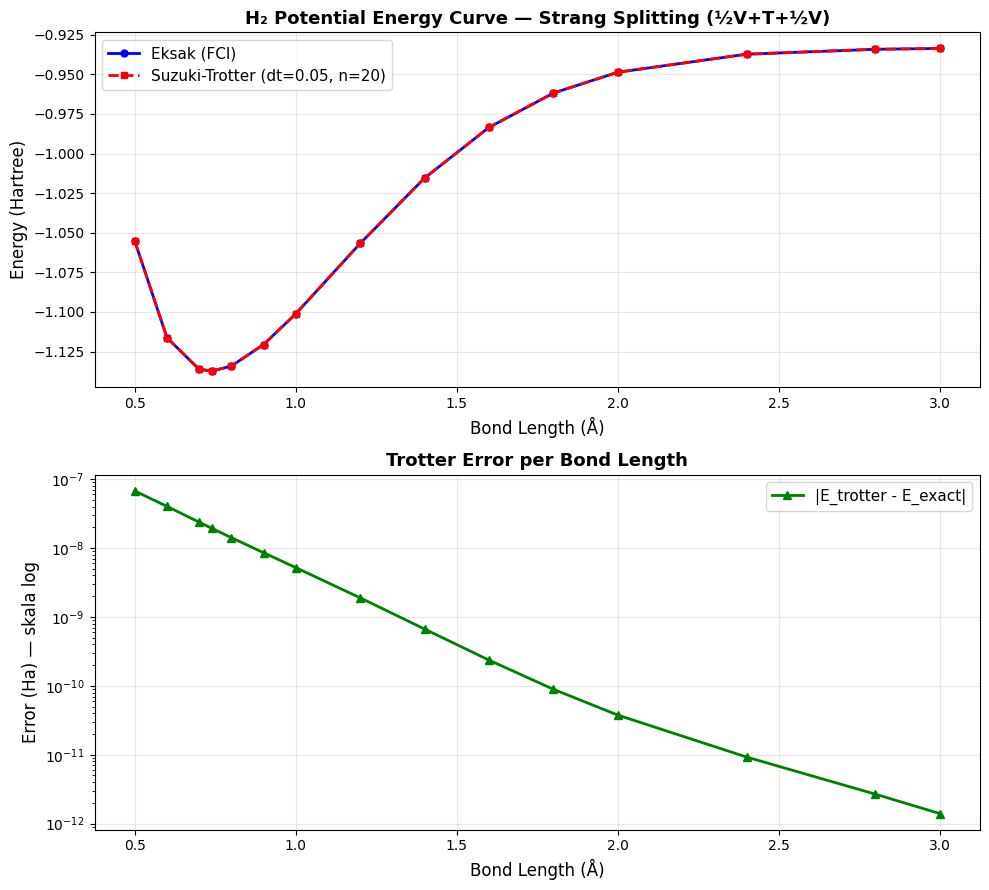

In [3]:
# ── Tabel ─────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
print("\n", df.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

bl = df['bond_length'].values

# Plot 1: Kurva energi
ax1.plot(bl, df['E_exact'],   'b-o', linewidth=2, markersize=5, label='Eksak (FCI)')
ax1.plot(bl, df['E_trotter'], 'r--s', linewidth=2, markersize=5,
         label=f'Suzuki-Trotter (dt={dt}, n={n_steps})')
ax1.set_xlabel('Bond Length (Å)', fontsize=12)
ax1.set_ylabel('Energy (Hartree)', fontsize=12)
ax1.set_title('H₂ Potential Energy Curve — Strang Splitting (½V+T+½V)', fontsize=13, weight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Error Trotter
ax2.semilogy(bl, df['selisih'], 'g-^', linewidth=2, markersize=6, label='|E_trotter - E_exact|')
ax2.set_xlabel('Bond Length (Å)', fontsize=12)
ax2.set_ylabel('Error (Ha) — skala log', fontsize=12)
ax2.set_title('Trotter Error per Bond Length', fontsize=13, weight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()